In [139]:
import numpy as np
import pandas as pd
import librosa as lb

In [140]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [141]:
import numpy as np
import pandas as pd

print("Working")

Working


In [142]:
pip install matplotlib seaborn

In [143]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display
import os

In [144]:
import tensorflow as tf
from tensorflow import keras

In [145]:
# to check if tensorflow is using gpu or not
len(tf.config.list_physical_devices('GPU')) > 0

False

In [146]:
patient_data = pd.read_csv(r"C:\SwaasAi\Respiratory_Sound_Database\Respiratory_Sound_Database\patient_diagnosis.csv",
                           names=['pid','disease'])

In [147]:
# printing patient id and disease info
patient_data.head()

,pid,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [148]:
# knowing the audio text files
df = pd.read_csv(r"C:\SwaasAi\Respiratory_Sound_Database\Respiratory_Sound_Database\audio_and_txt_files\203_1p4_Tc_mc_AKGC417L.txt",sep='\t',names=['start','end','crackles','wheezes'])
df.head()


,start,end,crackles,wheezes
0,0.685,2.208,0,0
1,2.208,4.577,1,0
2,4.577,6.970,1,0
3,6.970,9.351,0,0
4,9.351,11.851,0,0


In [149]:
# taking the file names
import os
path=r"C:\SwaasAi\Respiratory_Sound_Database\Respiratory_Sound_Database\audio_and_txt_files"
files=[s.split('.')[0] for s in os.listdir(path) if '.txt' in s]
files[:5]

['101_1b1_Al_sc_Meditron',
 '101_1b1_Pr_sc_Meditron',
 '102_1b1_Ar_sc_Meditron',
 '103_2b2_Ar_mc_LittC2SE',
 '104_1b1_Al_sc_Litt3200']

In [150]:
def getFilenameInfo(file):
    return file.split('_')

In [151]:
getFilenameInfo('101_1b1_Al_sc_Meditron')

['101', '1b1', 'Al', 'sc', 'Meditron']

In [152]:
import os

files_data = []

for file in files:
    file_path = os.path.join(path, file + ".txt")   # ✅ fix path

    data = pd.read_csv(
        file_path,
        sep="\t",
        names=['start','end','crackles','wheezes']
    )

    name_data = getFilenameInfo(file)

    data['pid'] = name_data[0]
    data['mode'] = name_data[-2]
    data['filename'] = file

    files_data.append(data)

# combine all
files_df = pd.concat(files_data, ignore_index=True)

# select only required columns
files_df = files_df[['start','end','crackles','wheezes','pid','mode','filename']]

# show output
files_df.head()

,start,end,crackles,wheezes,pid,mode,filename
0,0.036,0.579,0,0,101,sc,101_1b1_Al_sc_Meditron
1,0.579,2.450,0,0,101,sc,101_1b1_Al_sc_Meditron
2,2.450,3.893,0,0,101,sc,101_1b1_Al_sc_Meditron
3,3.893,5.793,0,0,101,sc,101_1b1_Al_sc_Meditron
4,5.793,7.521,0,0,101,sc,101_1b1_Al_sc_Meditron


In [153]:
patient_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   pid      126 non-null    int64 
 1   disease  126 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


In [154]:
files_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   start     6898 non-null   float64
 1   end       6898 non-null   float64
 2   crackles  6898 non-null   int64  
 3   wheezes   6898 non-null   int64  
 4   pid       6898 non-null   object 
 5   mode      6898 non-null   object 
 6   filename  6898 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 377.4+ KB


In [155]:
patient_data.pid=patient_data.pid.astype('int32')
files_df.pid=files_df.pid.astype('int32')

In [156]:
data=pd.merge(files_df,patient_data,on='pid')
data.head()

,start,end,crackles,wheezes,pid,mode,filename,disease
0,0.036,0.579,0,0,101,sc,101_1b1_Al_sc_Meditron,URTI
1,0.579,2.450,0,0,101,sc,101_1b1_Al_sc_Meditron,URTI
2,2.450,3.893,0,0,101,sc,101_1b1_Al_sc_Meditron,URTI
3,3.893,5.793,0,0,101,sc,101_1b1_Al_sc_Meditron,URTI
4,5.793,7.521,0,0,101,sc,101_1b1_Al_sc_Meditron,URTI


In [157]:
import os

if not os.path.exists('csv_data'):
    os.makedirs('csv_data')

# save file
files_df.to_csv('csv_data/data.csv', index=False)

# check again AFTER creation
isCsvDataExist = os.path.exists('csv_data')

print(isCsvDataExist)

True


In [158]:
'''
    Takes a numpy array and spilts its using start and end args
    
    raw_data=numpy array of audio sample
    start=time
    end=time
    sr=sampling_rate
    mode=mono/stereo
    by default librosa gives sr=22050
'''
def getPureSample(raw_data,start,end,sr):
    max_ind = len(raw_data) 
    start_ind = min(int(start * sr), max_ind)
    end_ind = min(int(end * sr), max_ind)
    return raw_data[start_ind: end_ind]

<Axes: xlabel='None', ylabel='pid'>

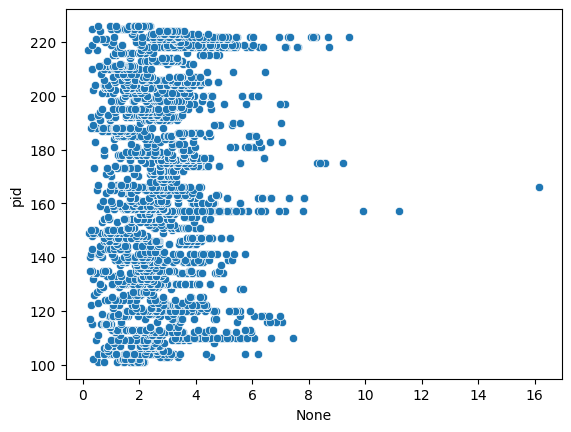

In [159]:
sns.scatterplot(x=(data.end-data.start), y=data.pid)

<Axes: ylabel='None'>

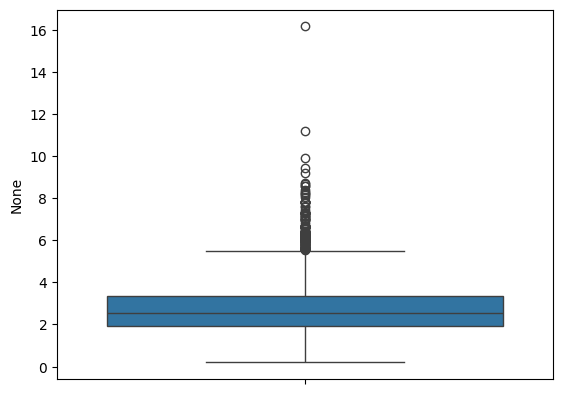

In [160]:
sns.boxplot(y=(data.end-data.start))

In [161]:
import os

# check & create folder
if not os.path.exists('processed_audio_files'):
    os.makedirs('processed_audio_files')

# check again AFTER creation
isProcessedAudioFilesExist = os.path.exists('processed_audio_files')

print(isProcessedAudioFilesExist)

True


In [162]:
import os
from scipy.io import wavfile   # ✅ replace librosa

for index, row in data.iterrows():
    print("Index:", index)
    print("DataRow:\n", row)

    # correct file path
    audio_file_loc = os.path.join(path, row['filename'] + '.wav')

    # load audio using scipy
    sampleRate, audioArr = wavfile.read(audio_file_loc)

    print("Sample Rate:", sampleRate)
    print("Audio Shape:", audioArr.shape)

    break

Index: 0
DataRow:
 start                        0.036
end                          0.579
crackles                         0
wheezes                          0
pid                            101
mode                            sc
filename    101_1b1_Al_sc_Meditron
disease                       URTI
Name: 0, dtype: object
Sample Rate: 44100
Audio Shape: (882000,)


In [163]:
isProcessedAudioFilesExistFlag = True

In [164]:
import soundfile as sf
import numpy as np
from scipy.io import wavfile
import os

isProcessedAudioFilesExistFlag = True

if isProcessedAudioFilesExistFlag:
    i, cnt = 0, 0

    for index, row in data.iterrows():
        maxLen = 6
        start = row['start']
        end = row['end']
        filename = row['filename']

        # limit duration
        if end - start > maxLen:
            end = start + maxLen

        audio_file_loc = os.path.join(path, filename + '.wav')

        if not os.path.exists(audio_file_loc):
            continue

        # rename logic
        if index > 0:
            if data.iloc[index-1]['filename'] == filename:
                i += 1
            else:
                i = 0

        new_filename = filename + '_' + str(i) + '.wav'
        save_path = 'processed_audio_files/' + new_filename

        cnt += 1

        # ✅ load audio (NO librosa)
        sampleRate, audioArr = wavfile.read(audio_file_loc)

        # convert to mono
        if len(audioArr.shape) > 1:
            audioArr = audioArr.mean(axis=1)

        # extract segment
        start_sample = int(start * sampleRate)
        end_sample = int(end * sampleRate)
        pureSample = audioArr[start_sample:end_sample]

        # padding
        reqLen = int(6 * sampleRate)

        if len(pureSample) < reqLen:
            padded_data = np.pad(pureSample, (0, reqLen - len(pureSample)))
        else:
            padded_data = pureSample[:reqLen]

        # save file
        sf.write(save_path, padded_data, sampleRate)

    print('Total Files Processed:', cnt)

Total Files Processed: 6898


EDA, Handling Imbalance & Creating Spectrogram

In [167]:
patient_info = pd.read_csv(
    r"C:\Users\DELL\OneDrive\Desktop\MCA project\Respiratory_Sound_Database\Respiratory_Sound_Database\demographic_info.txt",
    names=['Patient', 'Age', 'Sex', 'BMI', 'Weight', 'Height'],
    sep='\s+'   # ✅ replaces deprecated delim_whitespace
)

In [168]:
patient_info.head()

,Patient,Age,Sex,BMI,Weight,Height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [169]:
patient_info['Sex'].value_counts()

Sex
M    79
F    46
Name: count, dtype: int64

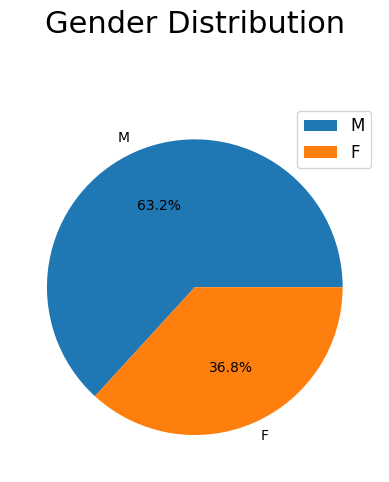

In [170]:
plt.pie(patient_info['Sex'].value_counts(), labels = ['M','F'], autopct='%1.1f%%')
plt.title("Gender Distribution", fontsize=22, pad=50.0)
plt.legend(fontsize=12, loc='best', bbox_to_anchor=(1, 1));
plt.show() 

In [171]:
import IPython.display as ipd

In [172]:
'''
Loading And Playing Audio Files
'''
filePath = 'processed_audio_files/226_1b1_Pl_sc_LittC2SE_7.wav'
ipd.Audio(filePath)

In [173]:
# librosa can convert stereo to mono audio
audio1,sample_rate1 = librosa.load(filePath,  mono=True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_7396\625880934.py:6: FutureWarning: waveshow() keyword argument 'x_axis' has been renamed to 'axis' in version 0.10.0.
	This alias will be removed in version 1.0.
  librosa.display.waveshow(audio1,sr=sample_rate1, max_points=50000, x_axis='time', offset=0)


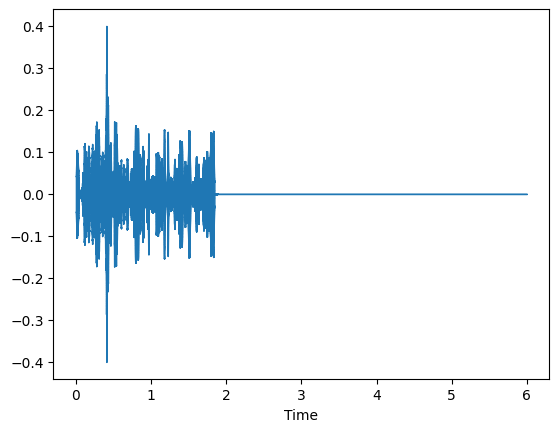

In [174]:
'''
The sampling rate is the number of samples per second. Hz or Hertz is the unit of the sampling rate.
20 kHz is the audible range for human beings.
'''

librosa.display.waveshow(audio1,sr=sample_rate1, max_points=50000, x_axis='time', offset=0)

In [175]:
import seaborn as sns
# patient_data = pd.read_csv('Respiratory_Sound_Database\Respiratory_Sound_Database\patient_diagnosis.csv',names=['pid','disease'])
patient_data.head()

,pid,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


C:\Users\DELL\AppData\Local\Temp\ipykernel_7396\1226301313.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'disease', data = patient_data, palette = "bright")


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'URTI'),
  Text(1, 0, 'Healthy'),
  Text(2, 0, 'Asthma'),
  Text(3, 0, 'COPD'),
  Text(4, 0, 'LRTI'),
  Text(5, 0, 'Bronchiectasis'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Bronchiolitis')])

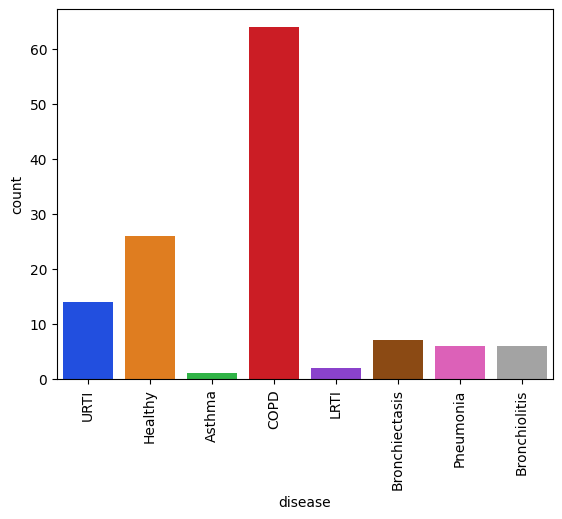

In [176]:
sns.countplot(x = 'disease', data = patient_data, palette = "bright")
plt.xticks(rotation=90)

In [177]:
# show count of each category in a column
patient_data['disease'].value_counts()

disease
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

In [180]:
def extractId(filename):
    return filename.split('_')[0]

In [181]:
import os
import pandas as pd

path = r"C:\Users\DELL\SwaasAi\processed_audio_files"

files = os.listdir(path)

files_df = pd.DataFrame(columns=['pid', 'filename'])

for i, f in enumerate(files):
    files_df.loc[i, 'pid'] = extractId(f)
    files_df.loc[i, 'filename'] = f

files_df.head()

,pid,filename
0,101,101_1b1_Al_sc_Meditron_0.wav
1,101,101_1b1_Al_sc_Meditron_1.wav
2,101,101_1b1_Al_sc_Meditron_10.wav
3,101,101_1b1_Al_sc_Meditron_11.wav
4,101,101_1b1_Al_sc_Meditron_2.wav


In [182]:
files_df.pid=files_df.pid.astype('int64') # both pid's must be of same dtype for them to merge

In [183]:
data=pd.merge(files_df,patient_data,on='pid')
data.head()

,pid,filename,disease
0,101,101_1b1_Al_sc_Meditron_0.wav,URTI
1,101,101_1b1_Al_sc_Meditron_1.wav,URTI
2,101,101_1b1_Al_sc_Meditron_10.wav,URTI
3,101,101_1b1_Al_sc_Meditron_11.wav,URTI
4,101,101_1b1_Al_sc_Meditron_2.wav,URTI


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'URTI'),
  Text(1, 0, 'Healthy'),
  Text(2, 0, 'Asthma'),
  Text(3, 0, 'COPD'),
  Text(4, 0, 'LRTI'),
  Text(5, 0, 'Bronchiectasis'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Bronchiolitis')])

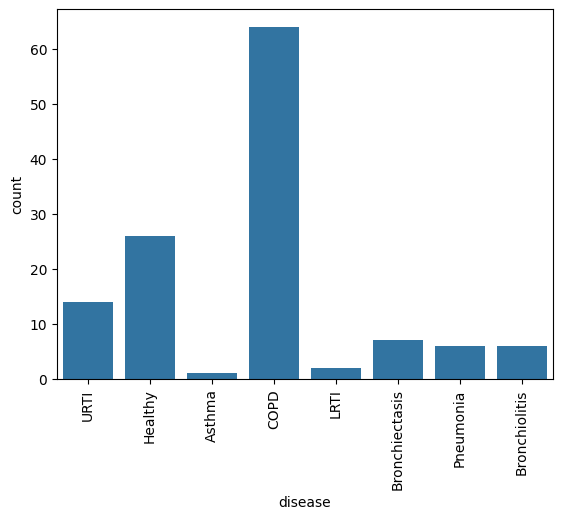

In [185]:
sns.countplot(x = 'disease', data = patient_data)
plt.xticks(rotation=90)

In [186]:
from sklearn.model_selection import train_test_split
Xtrain,Xval,ytrain,yval=train_test_split(data,data.disease,stratify=data.disease,random_state=42,test_size=0.25)

In [187]:
Xtrain.disease.value_counts()/Xtrain.shape[0]

disease
COPD              0.832979
Healthy           0.046588
Pneumonia         0.041369
URTI              0.035183
Bronchiolitis     0.023197
Bronchiectasis    0.015078
LRTI              0.004639
Asthma            0.000967
Name: count, dtype: float64

In [188]:
Xval.disease.value_counts()/Xval.shape[0]

disease
COPD              0.833043
Healthy           0.046957
Pneumonia         0.041159
URTI              0.035362
Bronchiolitis     0.023188
Bronchiectasis    0.015072
LRTI              0.004638
Asthma            0.000580
Name: count, dtype: float64

[Text(0.5, 1.0, 'MFCC')]

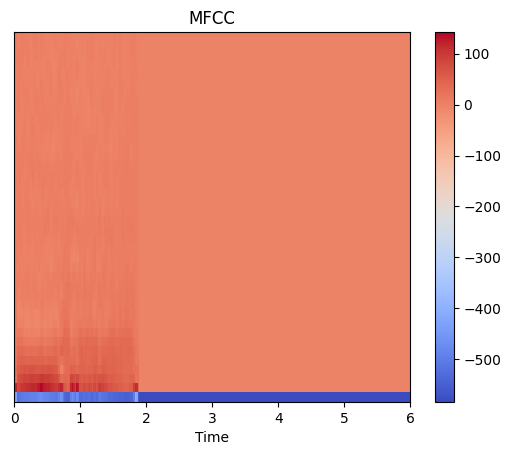

In [189]:
# Using one file for demo
sound,sample_rate=librosa.load(filePath)
mfccs = librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40)
fig, ax = plt.subplots()
img = librosa.display.specshow(mfccs, x_axis='time', ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='MFCC')


In [190]:
mfccs.shape

(40, 259)

In [191]:

Xtrain.head()

,pid,filename,disease
1650,133,133_2p4_Pr_mc_AKGC417L_0.wav,COPD
2672,152,152_1b1_Al_sc_Meditron_6.wav,Healthy
548,112,112_1p1_Pr_sc_Litt3200_8.wav,COPD
4733,179,179_1b1_Al_sc_Meditron_6.wav,Healthy
1438,130,130_3p2_Ar_mc_AKGC417L_6.wav,COPD


In [192]:

ytrain.head()

1650       COPD
2672    Healthy
548        COPD
4733    Healthy
1438       COPD
Name: disease, dtype: object

In [193]:
Xval.head()

,pid,filename,disease
3592,163,163_2b2_Tc_mc_AKGC417L_4.wav,COPD
3286,158,158_2p3_Lr_mc_AKGC417L_11.wav,COPD
1051,130,130_1p2_Pr_mc_AKGC417L_3.wav,COPD
631,114,114_1b4_Pr_mc_AKGC417L_4.wav,COPD
5135,192,192_2b2_Ar_mc_LittC2SE_6.wav,COPD


In [194]:
yval.head

<bound method NDFrame.head of 3592    COPD
3286    COPD
1051    COPD
631     COPD
5135    COPD
        ... 
1917    COPD
4928    COPD
5283    COPD
2874    COPD
1946    COPD
Name: disease, Length: 1725, dtype: object>

In [199]:
# Save training and validation data
TrainingFileExist = os.path.exists('training')
ValidationFileExist = os.path.exists('validation')
if(not TrainingFileExist):
    os.makedirs('training')
    Xtrain.to_csv('training/train.csv')
if(not ValidationFileExist):
    os.makedirs('validation')
    Xval.to_csv('validation/val.csv')

In [200]:
train=pd.read_csv('training/train.csv')
val=pd.read_csv('validation/val.csv')
train.head()

,Unnamed: 0,pid,filename,disease
0,1636,207,207_2b2_Al_mc_AKGC417L.txt,COPD
1,92,109,109_1b1_Pl_sc_Litt3200.txt,COPD
2,1639,207,207_2b2_Ar_mc_AKGC417L.wav,COPD
3,1092,174,174_1p2_Pr_mc_AKGC417L.txt,COPD
4,295,130,130_2b4_Ar_mc_AKGC417L.wav,COPD


In [197]:
train=pd.read_csv('training/train.csv')
val=pd.read_csv('validation/val.csv')
train.head()


,Unnamed: 0,pid,filename,disease
0,1636,207,207_2b2_Al_mc_AKGC417L.txt,COPD
1,92,109,109_1b1_Pl_sc_Litt3200.txt,COPD
2,1639,207,207_2b2_Ar_mc_AKGC417L.wav,COPD
3,1092,174,174_1p2_Pr_mc_AKGC417L.txt,COPD
4,295,130,130_2b4_Ar_mc_AKGC417L.wav,COPD


In [198]:
ytrain=train.disease
yval=val.disease
yval

0      Pneumonia
1           COPD
2           COPD
3           COPD
4        Healthy
         ...    
455         COPD
456         COPD
457         COPD
458         COPD
459         COPD
Name: disease, Length: 460, dtype: object

In [64]:
yval.info()

<class 'pandas.core.series.Series'>
Index: 1725 entries, 3592 to 1946
Series name: disease
Non-Null Count  Dtype 
--------------  ----- 
1725 non-null   object
dtypes: object(1)
memory usage: 27.0+ KB


In [65]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
ytrain=le.fit_transform(ytrain)
yval=le.transform(yval)

In [66]:
yval

array([3, 3, 3, ..., 3, 3, 3], shape=(1725,))

Feature Extraction

In [88]:
from scipy.io import wavfile
import numpy as np
from scipy.fftpack import dct

def getFeatures(p):
    sr, x = wavfile.read(p)
    if len(x.shape)>1: x=x.mean(axis=1)
    x = x/np.max(np.abs(x))

    frames = np.array([x[i:i+int(0.025*sr)]
                       for i in range(0, len(x)-int(0.025*sr), int(0.01*sr))])

    fft = np.abs(np.fft.rfft(frames,512))
    log_fft = np.log(fft+1e-10)

    mfcc = dct(log_fft, axis=1)[:,:40]      # MFCC
    cstft = log_fft[:,:40]                  # fake chroma-like
    mSpec = fft[:,:40]                      # mel-like approx

    # padding
    def fix(a): return np.pad(a,((0,max(0,100-a.shape[0])),(0,0)))[:100]

    return fix(mfcc), fix(cstft), fix(mSpec)

In [89]:
import os, numpy as np

root = 'processed_audio_files'
files = [f for f in os.listdir(root) if f.endswith('.wav')]

mfcc, cstft, mSpec = [], [], []

for f in files:
    a,b,c = getFeatures(os.path.join(root,f))
    mfcc.append(a); cstft.append(b); mSpec.append(c)

mfcc_train  = np.array(mfcc)
cstft_train = np.array(cstft)
mSpec_train = np.array(mSpec)

print(mfcc_train.shape, cstft_train.shape, mSpec_train.shape)

(6898, 100, 40) (6898, 100, 40) (6898, 100, 40)


In [90]:
mfcc_train

array([[[-1.24899893e+03,  2.61722356e+02,  1.32539438e+02, ...,
          8.81653502e+00,  8.61293457e+00,  7.23899913e+00],
        [-1.35981855e+03,  2.60131366e+02,  1.30124822e+02, ...,
          8.64522236e+00,  6.11214407e+00,  7.93488868e+00],
        [-1.23248774e+03,  2.59320888e+02,  1.30283978e+02, ...,
          5.26856656e+00,  7.46382519e+00,  5.06322251e+00],
        ...,
        [-1.18352874e+04,  3.22543021e-14,  4.36086617e-14, ...,
         -2.01702443e-13, -3.45613887e-14, -1.81539042e-13],
        [-1.18352874e+04,  3.22543021e-14,  4.36086617e-14, ...,
         -2.01702443e-13, -3.45613887e-14, -1.81539042e-13],
        [-1.18352874e+04,  3.22543021e-14,  4.36086617e-14, ...,
         -2.01702443e-13, -3.45613887e-14, -1.81539042e-13]],

       [[-2.10418483e+03,  2.68931865e+02,  1.43950045e+02, ...,
          1.11855084e+01,  1.75395765e+01,  1.56163910e+01],
        [-8.11618749e+02,  2.62397883e+02,  1.33152405e+02, ...,
          8.29526223e+00,  7.78837585e

In [91]:
# saving variables so we do not have to extract them again
# convert 3d arr to 2d to save it
# while loading need to reshape back to 3d

mfcc_reshaped = mfcc_train.reshape(mfcc_train.shape[0], -1)
cstft_reshaped = cstft_train.reshape(cstft_train.shape[0], -1)
mSpec_reshaped = mSpec_train.reshape(mSpec_train.shape[0], -1)
print(mfcc_reshaped)
np.savetxt('mfcc_variable_train.txt', mfcc_reshaped)
np.savetxt('cstft_variable_train.txt', cstft_reshaped)
np.savetxt('mSpec_variable_train.txt', mSpec_reshaped)

[[-1.24899893e+03  2.61722356e+02  1.32539438e+02 ... -2.01702443e-13
  -3.45613887e-14 -1.81539042e-13]
 [-2.10418483e+03  2.68931865e+02  1.43950045e+02 ...  1.09024332e+01
   1.05756496e+01  9.81606013e+00]
 [-1.14694102e+03  2.62047740e+02  1.33522948e+02 ...  5.88025893e+00
   6.08100810e+00  6.46705847e+00]
 ...
 [-9.26210272e+02  2.63579108e+02  1.33604690e+02 ...  3.86588941e+00
   2.80484151e+00  2.88790876e+00]
 [-6.74150303e+02  2.63169635e+02  1.34699291e+02 ...  6.60129671e+00
   6.36495882e+00  6.14436050e+00]
 [-9.94801271e+02  2.62703291e+02  1.32067594e+02 ...  1.18083087e+01
   1.15277310e+01  1.16977044e+01]]


In [103]:
# loading variable files
mfcc_train = np.loadtxt('mfcc_variable_train.txt')
cstft_train = np.loadtxt('cstft_variable_train.txt')
mSpec_train = np.loadtxt('mSpec_variable_train.txt')

In [104]:

mfcc_train

array([[-1.24899893e+03,  2.61722356e+02,  1.32539438e+02, ...,
        -2.01702443e-13, -3.45613887e-14, -1.81539042e-13],
       [-2.10418483e+03,  2.68931865e+02,  1.43950045e+02, ...,
         1.09024332e+01,  1.05756496e+01,  9.81606013e+00],
       [-1.14694102e+03,  2.62047740e+02,  1.33522948e+02, ...,
         5.88025893e+00,  6.08100810e+00,  6.46705847e+00],
       ...,
       [-9.26210272e+02,  2.63579108e+02,  1.33604690e+02, ...,
         3.86588941e+00,  2.80484151e+00,  2.88790876e+00],
       [-6.74150303e+02,  2.63169635e+02,  1.34699291e+02, ...,
         6.60129671e+00,  6.36495882e+00,  6.14436050e+00],
       [-9.94801271e+02,  2.62703291e+02,  1.32067594e+02, ...,
         1.18083087e+01,  1.15277310e+01,  1.16977044e+01]],
      shape=(6898, 4000))

In [110]:
mfcc_train.shape

(6898, 100, 40)

In [111]:
cstft_train.shape

(6898, 4000)

In [112]:
mSpec_train.shape

(6898, 4000)

BUILDING MODEL

In [116]:
# Lets create model using Keras Functional API to check how the features perform.
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=3, min_lr=0.00001,mode='min')
]

In [117]:
mfcc_input=keras.layers.Input(shape=(20,259,1),name="mfccInput")
x=keras.layers.Conv2D(32,5,strides=(1,3),padding='same')(mfcc_input)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(64,3,strides=(1,2),padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(96,2,padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(128,2,padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
mfcc_output=keras.layers.GlobalMaxPooling2D()(x)

mfcc_model=keras.Model(mfcc_input, mfcc_output, name="mfccModel")

In [118]:
mfcc_model.summary()

Model: "mfccModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfccInput (InputLayer)          │ (None, 20, 259, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 20, 87, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 87, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 11, 96)      │        24,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 11, 96)      │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 5, 11, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 5, 128)      │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,560 (369.38 KB)

 Trainable params: 93,920 (366.88 KB)

 Non-trainable params: 640 (2.50 KB)

In [119]:
croma_input=keras.layers.Input(shape=(12,259,1),name="cromaInput")
x=keras.layers.Conv2D(32,5,strides=(1,3),padding='same')(croma_input)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(64,3,strides=(1,2),padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(128,2,padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
croma_output=keras.layers.GlobalMaxPooling2D()(x)

croma_model=keras.Model(croma_input, croma_output, name="cromaModel")

In [120]:
croma_model.summary()

Model: "cromaModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cromaInput (InputLayer)         │ (None, 12, 259, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 87, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 87, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 43, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 22, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 22, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 6, 22, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 11, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 11, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 3, 11, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,120 (207.50 KB)

 Trainable params: 52,672 (205.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [121]:
mSpec_input=keras.layers.Input(shape=(128,259,1),name="mSpecInput")
x=keras.layers.Conv2D(32,5,strides=(2,3),padding='same')(mSpec_input)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(64,3,strides=(2,2),padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(96,2,padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
x=keras.layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=keras.layers.Conv2D(128,2,padding='same')(x)
x=keras.layers.BatchNormalization()(x)
x=keras.layers.Activation(keras.activations.relu)(x)
mSpec_output=keras.layers.GlobalMaxPooling2D()(x)

mSpec_model=keras.Model(mSpec_input, mSpec_output, name="mSpecModel")

In [122]:
mSpec_model.summary()

Model: "mSpecModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mSpecInput (InputLayer)         │ (None, 128, 259, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 87, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 87, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 11, 96)      │        24,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 11, 96)      │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 11, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 5, 128)      │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 4, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,560 (369.38 KB)

 Trainable params: 93,920 (366.88 KB)

 Non-trainable params: 640 (2.50 KB)

In [123]:
input_mfcc=keras.layers.Input(shape=(20,259,1),name="mfcc")
mfcc=mfcc_model(input_mfcc)

input_croma=keras.layers.Input(shape=(12,259,1),name="croma")
croma=croma_model(input_croma)

input_mSpec=keras.layers.Input(shape=(128,259,1),name="mspec")
mSpec=mSpec_model(input_mSpec)


concat=keras.layers.concatenate([mfcc,croma,mSpec])
hidden=keras.layers.Dropout(0.1)(concat)
hidden=keras.layers.Dense(50,activation='relu')(concat)
hidden=keras.layers.Dropout(0.2)(hidden)
hidden=keras.layers.Dense(25,activation='relu')(hidden)
hidden=keras.layers.Dropout(0.2)(hidden)
output=keras.layers.Dense(8,activation='softmax')(hidden)

net=keras.Model([input_mfcc,input_croma,input_mSpec], output, name="Net")

In [124]:
net.summary()

Model: "Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc (InputLayer)   │ (None, 20, 259,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ croma (InputLayer)  │ (None, 12, 259,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mspec (InputLayer)  │ (None, 128, 259,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfccModel           │ (None, 128)       │     94,560 │ mfcc[0][0]        │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cromaModel          │ (None, 128)       │     53,120 │ croma[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mSpecModel          │ (None, 128)       │     94,560 │ mspec[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ mfccModel[0][0],  │
│ (Concatenate)       │                   │            │ cromaModel[0][0], │
│                     │                   │            │ mSpecModel[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │     19,250 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 25)        │      1,275 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 25)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        208 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 262,973 (1.00 MB)

 Trainable params: 261,245 (1020.49 KB)

 Non-trainable params: 1,728 (6.75 KB)

In [125]:
keras.utils.plot_model(net, "combined_model.png", show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [127]:
net.compile(loss='sparse_categorical_crossentropy', optimizer='nadam', metrics=['accuracy'])

# Set learning rate directly
net.optimizer.learning_rate = 0.001

# Verify
print(f"Learning rate: {net.optimizer.learning_rate}")

Learning rate: <Variable path=nadam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>


In [129]:
print("mfcc_train:", mfcc_train.shape[0])
print("cstft_train:", cstft_train.shape[0])
print("mSpec_train:", mSpec_train.shape[0])
print("ytrain:", ytrain.shape[0])

mfcc_train: 6898
cstft_train: 6898
mSpec_train: 6898
ytrain: 5173


In [130]:
print("train df size:", len(train))
print("val df size:", len(val))
print("ytrain unique:", np.unique(ytrain))

train df size: 1380
val df size: 460
ytrain unique: [0 1 2 3 4 5 6 7]


In [131]:
# Rebuild ytrain from the same source as your features
ytrain = train['label'].values  # or whatever your label column is called
yval = val['label'].values
print(ytrain.shape, yval.shape)

KeyError: 'label'

In [135]:
# Track valid indices during feature extraction
mfcc, cstft, mSpec, valid_labels = [], [], [], []

for idx, row in train.iterrows():
    path = os.path.join(root, row['filename'].strip())
    if not os.path.exists(path):
        print(f"Skipping: {path}")
        continue
    try:
        a, b, c = getFeatures(path)
        mfcc.append(a)
        cstft.append(b)
        mSpec.append(c)
        valid_labels.append(row['label'])  # ✅ only append label if file succeeded
    except Exception as e:
        print(f"Error: {path}: {e}")
        continue

mfcc_train  = np.array(mfcc)
cstft_train = np.array(cstft)
mSpec_train = np.array(mSpec)
ytrain      = np.array(valid_labels)  # ✅ aligned with features

print(mfcc_train.shape, ytrain.shape)  # must match

Skipping: processed_audio_files\207_2b2_Al_mc_AKGC417L.txt
Skipping: processed_audio_files\109_1b1_Pl_sc_Litt3200.txt
Skipping: processed_audio_files\207_2b2_Ar_mc_AKGC417L.wav
Skipping: processed_audio_files\174_1p2_Pr_mc_AKGC417L.txt
Skipping: processed_audio_files\130_2b4_Ar_mc_AKGC417L.wav
Skipping: processed_audio_files\169_1b2_Ll_sc_Meditron.wav
Skipping: processed_audio_files\162_2b3_Ar_mc_AKGC417L.txt
Skipping: processed_audio_files\162_2b4_Pr_mc_AKGC417L.txt
Skipping: processed_audio_files\170_2b2_Al_mc_AKGC417L.wav
Skipping: processed_audio_files\113_1b1_Ll_sc_Litt3200.wav
Skipping: processed_audio_files\159_1b1_Ll_sc_Meditron.txt
Skipping: processed_audio_files\207_2b3_Ar_mc_AKGC417L.wav
Skipping: processed_audio_files\120_1b1_Lr_sc_Meditron.wav
Skipping: processed_audio_files\204_2b5_Ll_mc_AKGC417L.txt
Skipping: processed_audio_files\122_2b2_Ar_mc_LittC2SE.txt
Skipping: processed_audio_files\116_1b2_Pl_sc_Meditron.wav
Skipping: processed_audio_files\151_3p2_Ar_mc_AKGC417L.w

In [134]:
print("mfcc_train shape:", mfcc_train.shape)    # should be (N, 20, 259, 1) or (N, 20, 259)
print("cstft_train shape:", cstft_train.shape)
print("mSpec_train shape:", mSpec_train.shape)

mfcc_train shape: (0,)
cstft_train shape: (0,)
mSpec_train shape: (0,)


In [133]:
history=net.fit(
    {"mfcc":mfcc_train,"croma":cstft_train,"mspec":mSpec_train},
    ytrain,
    validation_data=({"mfcc":mfcc_val,"croma":cstft_val,"mspec":mSpec_val},yval),
    epochs=100,verbose=1,
    callbacks=my_callbacks
)

Epoch 1/100


ValueError: Exception encountered when calling Functional.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32,), dtype=float32). Expected shape (None, 20, 259, 1), but input has incompatible shape (32,)[0m

Arguments received by Functional.call():
  • inputs={'mfcc': 'tf.Tensor(shape=(32,), dtype=float32)', 'croma': 'tf.Tensor(shape=(32,), dtype=float32)', 'mspec': 'tf.Tensor(shape=(32,), dtype=float32)'}
  • training=True
  • mask={'mfcc': 'None', 'croma': 'None', 'mspec': 'None'}
  • kwargs=<class 'inspect._empty'>